# Comunidades en los grafos
 Detectar la partición óptima (según la modularidad) utilizando el algoritmo de Louvain. Reportar el valor de modularidad obtenido. Visualizar las comunidades en el grafo y evaluar cualitativamente el resultado. Comparar entre
los datasets analizados. Probar también con el algoritmo de Girvan-Newman y comparar resultados. 


## Aeropuertos
Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos, y los enlaces representan vuelos realizados en el año 2025. El peso de cada enlace indica el número total de vuelos de dicha ruta. Hay información sobre las coordenadas espaciales de cada aeropuerto. Contiene 1252 nodos y 23092 enlaces.

In [2]:
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl

import pandas as pd
import pickle

Para cargar datos

In [3]:
dir = "../data/airport_graph.csv"


# EDGES - aristas
df_edges = pd.read_csv(dir)
df_edges.rename(columns={'PASSENGERS': 'weight'}, inplace=True)
G = nx.from_pandas_edgelist(
    df_edges,
    source='ORIGIN_AIRPORT_ID',
    target='DEST_AIRPORT_ID',
    edge_attr='weight',
    create_using=nx.DiGraph()
)




In [4]:
# NODES (coords)
df_nodes_coords = pd.read_csv('../data/airport_coords.csv')

# attrs = df_nodes.set_index('AIRPORT_ID')[['LATITUDE','LONGITUDE']].to_dict('index')
# nx.set_node_attributes(G, attrs)

In [60]:

# for i in attrs.values():
#     # print(attrs[i]["LATITUDE"])
#     print(i)
latitud = []
longitud = []
clave = list(attrs.keys())
for i in clave:
    latitud.append(attrs[i]["LATITUDE"])
    longitud.append(attrs[i]["LONGITUDE"])



In [5]:
print('Airport')
print(G)
print('Es dirigido?:',nx.is_directed(G))
print('Es pesado?:',nx.is_weighted(G))
print('Es fuertemente conexo?:',nx.is_strongly_connected(G))
print('Es debilmente conexo?:',nx.is_weakly_connected(G))

Airport
DiGraph with 1252 nodes and 23092 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: False
Es debilmente conexo?: False


## Limpieza
Para grafos no dirigidos, si el grafo no es conectado analizar la com-
ponente gigante únicamente. Para grafos dirigidos analizar solo la componente fuertemente
conectada. En ambos casos, eliminar autoenlaces (enlaces que nodos realicen a sí mismos),
si los hubiere

In [6]:
# Borro autoenlaces
G.remove_edges_from(nx.selfloop_edges(G)) 

# airUndir = nx.DiGraph.to_undirected(air)

# Componente fuertemente conectada
Gcc = sorted(nx.strongly_connected_components(G) , key=len, reverse=True)

airStrongly = G.subgraph(Gcc[0])
print(airStrongly)
print('Es dirigido?:',nx.is_directed(airStrongly))
print('Es pesado?:',nx.is_weighted(airStrongly))
print('Es fuertemente conexo?:',nx.is_strongly_connected(airStrongly))
print('Es debilmente conexo?:',nx.is_weakly_connected(airStrongly))

DiGraph with 1130 nodes and 22796 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: True
Es debilmente conexo?: True


## Vizualización

In [7]:
# Se corre así para un grafo "G", y me devuelve un diccionario "pos" de posiciones
pos = nx.spring_layout(airStrongly,iterations=100)

In [8]:
def plotWeightedGraph(G, pos, colorMapping, magnification, nodeSize=45):
  values = [v for n,v in colorMapping.items()]
  nx.draw_networkx_nodes(G, pos=pos, node_size=nodeSize, node_color=values)

  edge_weights = nx.get_edge_attributes(G, "weight")
  edgeWidths = np.array(list(edge_weights.values()))
  edgeWidths = magnification * edgeWidths / np.max(edgeWidths)
  edgeWidths[edgeWidths > 0] = edgeWidths[edgeWidths > 0] - np.min(edgeWidths[edgeWidths > 0]) + .5

  nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edgeWidths, edge_color='gray')

Grafico el grafo con la componente altamente conectada

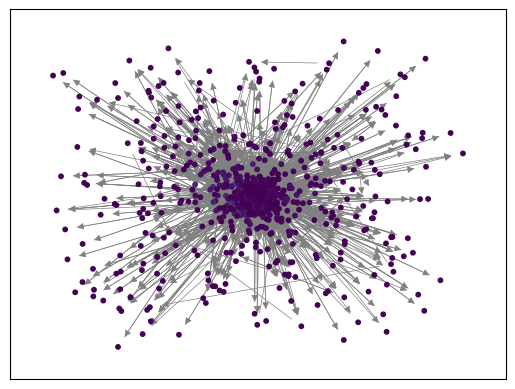

In [9]:
centrality = nx.degree_centrality(airStrongly)
magnification = 15
nodeSize = 10

plotWeightedGraph(airStrongly, pos, centrality, magnification, nodeSize)

Ahora el grafo enterno

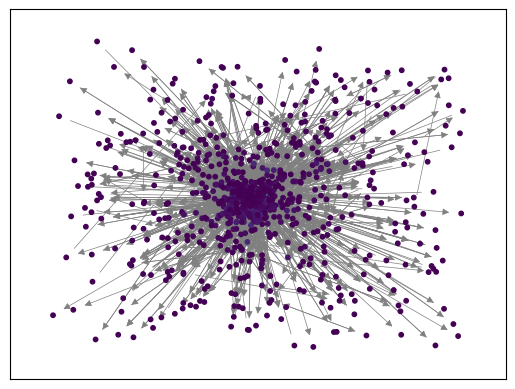

In [13]:
# Se corre así para un grafo "G", y me devuelve un diccionario "pos" de posiciones
pos = nx.spring_layout(G,iterations=100)
# El color de los nodos va a estar relacionado a su centralidad
centrality = nx.degree_centrality(G)
plotWeightedGraph(G, pos, centrality, magnification, nodeSize)

### Louvian
Para el método de Louvain usamos la librería community.community_louvain que importamos como cl

Para la red Observada obtenemos:

La modularidad de la partición óptima es: 0.20102075366292227



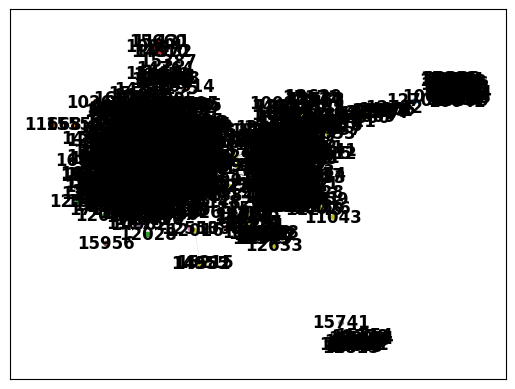

In [92]:
# quito la direccionalidad
G_obs = airStrongly.to_undirected()
# Se corre así para un grafo "G", y me devuelve un diccionario "pos" de posiciones
# pos = nx.spring_layout(G_obs,iterations=1000)
layout_obs = pos

# Mejor partición
modulos = cl.best_partition(G_obs)
print('La modularidad de la partición óptima es:', cl.modularity(modulos, G_obs))
print('')
values_per = [v for n,v in modulos.items()]

nx.draw_networkx_nodes(G_obs, layout_obs, node_size=10, node_color=values_per, cmap=plt.cm.tab10)
#¿por quue tengo que pasar nodos y aristas?
nx.draw_networkx_labels(G_obs, layout_obs, font_weight='bold', font_color='black')
edge_weights_obs = nx.get_edge_attributes(G_obs, "weight")
edgeWidth_obs = np.array(list(edge_weights_obs.values()))
edgeWidth_obs = edgeWidth_obs/np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_obs, layout_obs, edgelist=G_obs.edges(), width=edgeWidth_obs)

plt.show()

### Girvan newman

Crea grafos desconectados removiendo aristas elegidas según su valor de centralidad de aristas por cercanía (edge betweenness centrality)

In [ ]:
# DEVUELVE UN ITERADOR modulos QUE ME DA LA COMUNIDADES QUE SURGEN AL IR ELIMINANDO ENLACES
modulos = nx.community.girvan_newman(G_obs) 

modularidad = [] # ESTE EL EL INDICE DE MODULARIDAD (Q) QUE QUEREMOS OPTIMIZAR
mod_max = -999
for communities in modulos:
    # CALCULAMOS Q PARA CADA ITERACION
    n_modularidad = nx.community.modularity(G_obs, tuple(sorted(c) for c in communities)) 
    modularidad.append(n_modularidad)
    # ME GUARDO LA MAXIMA MODULARIDAD ENCONTRADA, Y LA PARTICIÓN DE COMUNIDADES CORRESPONDIENTE
    if n_modularidad > mod_max: 
      mod_max = n_modularidad
      com_max = tuple(sorted(c) for c in communities)

k = np.argmax(modularidad)
print('La modularidad de la partición óptima es:', mod_max)
print('La partición óptima tiene ',len(com_max), ' comunidades')
print('La partición óptima es:', com_max)

In [ ]:
# ¿Cómo cambia la modularidad Q a medida que vamos haciendo cortes en en el dendrograma?
plt.plot(modularidad)
plt.xlabel('Iteración')
plt.ylabel('Modularidad (Q)')

plt.show()

In [ ]:
layout = pos
# uso como label (color) la comunidad a la que pertenece cada nodo
values = [v for n, v in partition_set_to_dict(com_max).items()] 

plt.figure()
nx.draw_networkx_nodes(G_obs, layout, node_size=20, node_color=values, cmap=plt.cm.tab10)
nx.draw_networkx_labels(G_obs, layout,font_weight='bold', font_color='white')
edge_weights_obs = nx.get_edge_attributes(G_obs, "weight")
edgeWidth_obs = np.array(list(edge_weights_obs.values()))
edgeWidth_obs = edgeWidth_obs / np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_obs, layout, edgelist=G_obs.edges(), width=edgeWidth_obs)

plt.show()

array([1.16173703e-05, 5.22781663e-04, 5.80868515e-05, ...,
       1.42893655e-03, 1.68451869e-03, 1.64966658e-02], shape=(13415,))

### Según sus coordenadas

In [46]:
list_nodos = list(airStrongly.nodes())
lat_lon = df_nodes_coords.loc[df_nodes_coords["AIRPORT_ID"].isin(list_nodos),["LATITUDE", "LONGITUDE"]].values
layout_coords = dict(zip(list_nodos,lat_lon))
layout_coords

{10001: array([  58.10944444, -152.90666667]),
 10056: array([  57.74527778, -152.88277778]),
 10006: array([  59.36277778, -153.43055556]),
 10009: array([ 42.29138889, -73.71027778]),
 10170: array([  35.98611111, -113.81694444]),
 11630: array([  64.36361111, -147.36527778]),
 10016: array([  58.4575    , -154.02333333]),
 10278: array([  57.27722222, -154.34222222]),
 10324: array([  58.06555556, -153.0725    ]),
 11513: array([  63.54111111, -150.995     ]),
 12705: array([  57.32305556, -153.14944444]),
 12712: array([  57.78083333, -152.39111111]),
 12743: array([  58.5625    , -152.59611111]),
 12771: array([  65.31166667, -143.13416667]),
 12785: array([  59.83333333, -152.58472222]),
 12854: array([  58.17194444, -152.89416667]),
 12869: array([  58.46444444, -152.59305556]),
 13863: array([  58.58305556, -152.44583333]),
 13888: array([ 29.72638889, -85.025     ]),
 15091: array([ 40.65166667, -75.44277778]),
 15446: array([ 32.40833333, -99.6825    ]),
 10135: array([  67.0

In [47]:
layout_coords[11150]

array([ 39.94305556, -91.19444444])

Graficamos componente gigante con las coordenadas provistas

KeyboardInterrupt: 

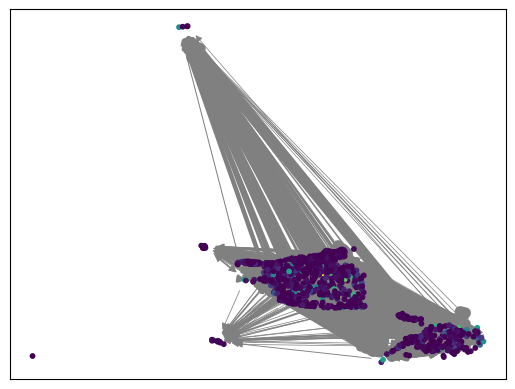

In [48]:
centrality = nx.degree_centrality(airStrongly)
magnification = 15
nodeSize = 10

plotWeightedGraph(airStrongly, layout_coords, centrality, magnification, nodeSize)

Ahora comunidades con Leuvian

La modularidad de la partición óptima es: 0.19655874341533267



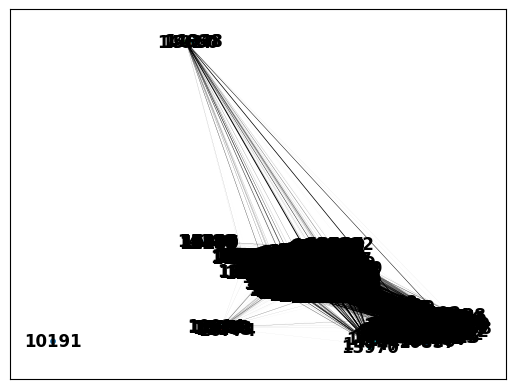

In [ ]:


# quito la direccionalidad
G_obs = airStrongly.to_undirected()
# layout
layout_obs = layout_coords
# Mejor partición
modulos = cl.best_partition(G_obs)
print('La modularidad de la partición óptima es:', cl.modularity(modulos, G_obs))
print('')
values_per = [v for n,v in modulos.items()]



Se observa comunidades mezcladas

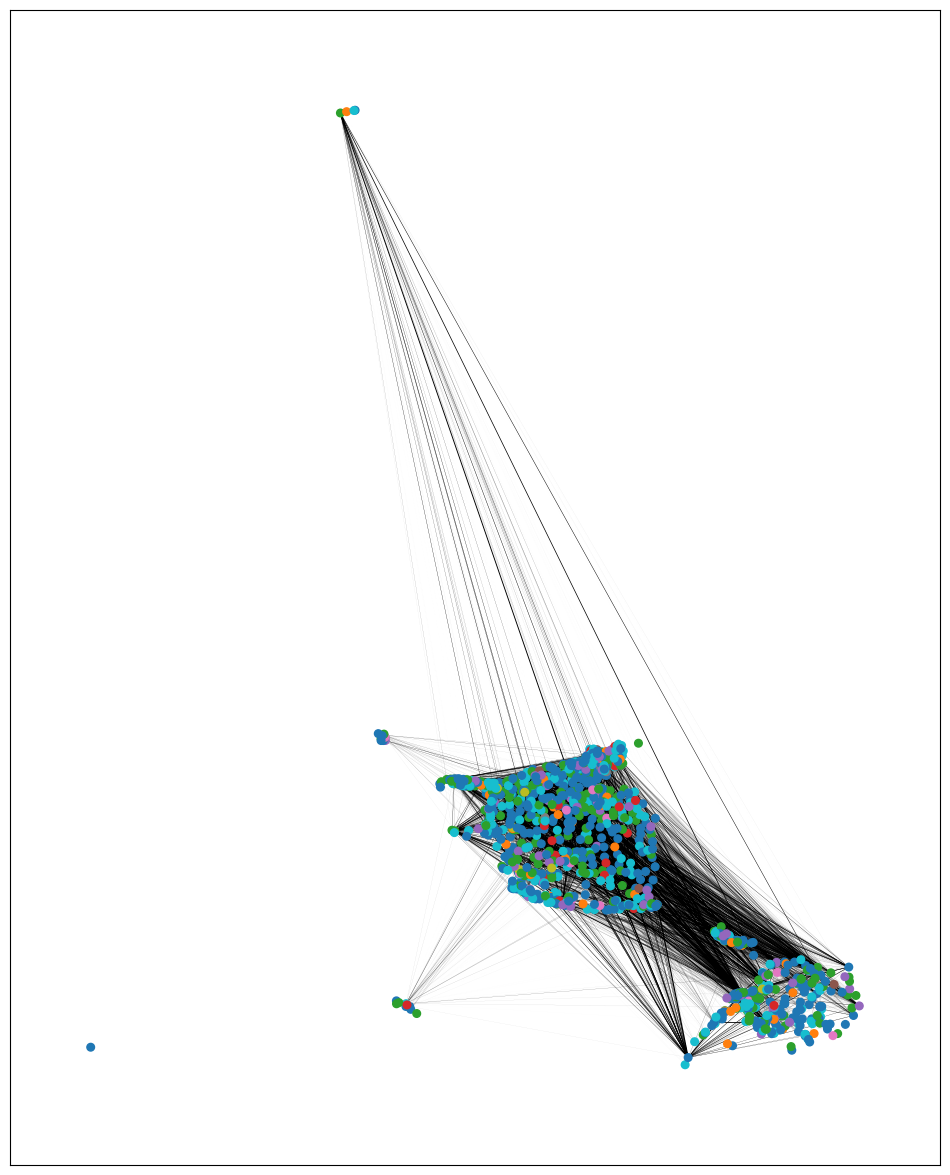

In [49]:
plt.figure(figsize=(12, 15))
nx.draw_networkx_nodes(G_obs, layout_obs, node_size=30, node_color=values_per, cmap=plt.cm.tab10)
#¿por quue tengo que pasar nodos y aristas?
# nx.draw_networkx_labels(G_obs, layout_obs, font_weight='bold', font_color='black')
edge_weights_obs = nx.get_edge_attributes(G_obs, "weight")
edgeWidth_obs = np.array(list(edge_weights_obs.values()))
edgeWidth_obs = edgeWidth_obs/np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_obs, layout_obs, edgelist=G_obs.edges(), width=edgeWidth_obs)

plt.show()

In [53]:
G_nx = G_obs
partition = cl.best_partition(G_nx)
modularity_louvain = cl.modularity(partition, G_nx)

n_communities_louvain = len(set(partition.values()))

print("Louvain:")
print("Número de comunidades:", n_communities_louvain)
print("Modularidad:", modularity_louvain)

Louvain:
Número de comunidades: 12
Modularidad: 0.19889278270783706


## Statick model SMB

In [54]:
import graph_tool.all as gt

ModuleNotFoundError: No module named 'graph_tool'